In [1]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import seaborn as sns

In [2]:
fda_data = pandas.read_csv("FDA Inspection Data.csv")
fda_data.head()

,FEI Number,Legal Name,City,State,Zip,Country/Area,Fiscal Year,Inspection ID,Posted Citations,Inspection End Date,Classification,Project Area,Product Type,Additional Details,FMD-145 Date
0,3003774440,Balzac Brothers & Company Inc.,Charleston,South Carolina,29401,United States,2026,1306888,No,03/19/2026,No Action Indicated (NAI),Foodborne Biological Hazards,Food/Cosmetics,FSVP,03/20/2026
1,3030120006,QUALITY BAKERIES LLC,Schaumburg,Illinois,60173,United States,2026,1305862,Yes,03/18/2026,Voluntary Action Indicated (VAI),Foodborne Biological Hazards,Food/Cosmetics,FSVP,-
2,3012215639,Enzyme Development Corporation,Scranton,Pennsylvania,18504,United States,2026,1306962,No,03/18/2026,No Action Indicated (NAI),Foodborne Biological Hazards,Food/Cosmetics,FSVP,-
3,1526344,Buehler Food Markets Inc,Wooster,Ohio,44691,United States,2026,1307882,Yes,03/17/2026,Voluntary Action Indicated (VAI),Foodborne Biological Hazards,Food/Cosmetics,FSVP,-
4,3015174757,Avena Foods USA Limited,Las Vegas,Nevada,89169,United States,2026,1308092,No,03/17/2026,No Action Indicated (NAI),Foodborne Biological Hazards,Food/Cosmetics,FSVP,-


In [3]:
# Ensure Zip variable is treated as numeric for LightGBM
fda_data['Zip'] = pandas.to_numeric(fda_data['Zip'], errors='coerce')

/var/folders/t7/pc4c9jtx7dd_r34vm3y6gw300000gn/T/ipykernel_57551/2738968335.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_counts.index, y=product_counts.values, palette='viridis')


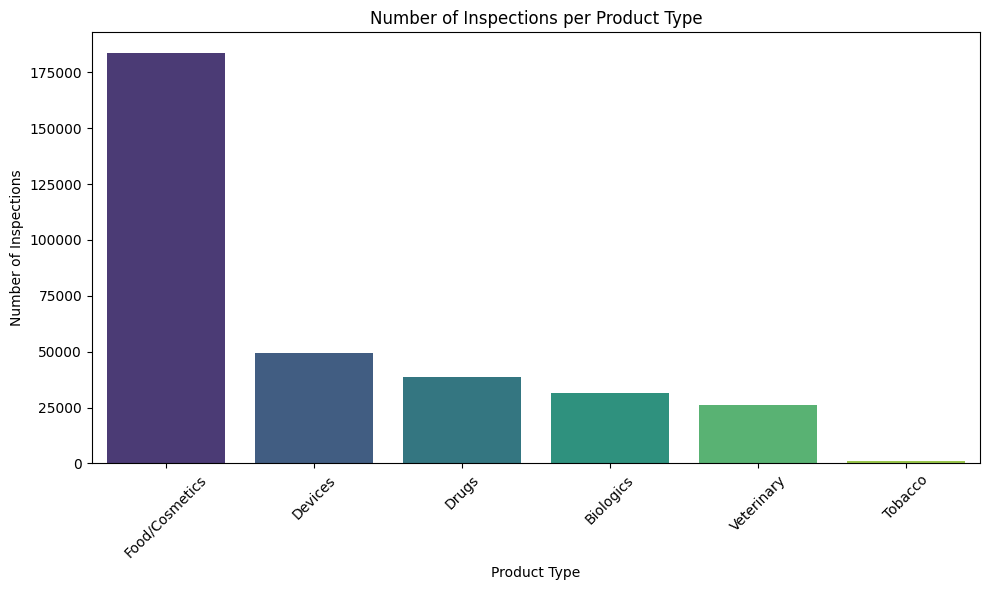

In [4]:
# Number of inspections per product type
product_counts = fda_data['Product Type'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=product_counts.index, y=product_counts.values, palette='viridis')
plt.title('Number of Inspections per Product Type')
plt.xlabel('Product Type')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# How many years of data do we have? Which years do we have?Use fiscal year for this.
fda_data['Fiscal Year'].unique()

array([2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016,
       2015, 2014, 2013, 2012, 2011, 2010, 2009])

In [6]:
# Classification of inspection outcomes:

# No action indicated (NAI),
# which means no objectionable conditions or practices were found during the inspection, 

#Voluntary action indicated (VAI), which means objectionable conditions or practices were found, 
# but the agency is not prepared to take or recommend any administrative or regulatory action

# Official action indicated (OAI), which means regulatory and/or administrative actions 
# are recommended. 

In [7]:
# Create three-class inspection outcome: 0 = NAI, 1 = VAI, 2 = OAI
outcome_map = {
    'No Action Indicated (NAI)': 0,
    'Voluntary Action Indicated (VAI)': 1,
    'Official Action Indicated (OAI)': 2
}

fda_data['Inspection Outcome'] = fda_data['Classification'].map(outcome_map).astype('Int64')

In [8]:
# How many inspections resulted in OAI vs VAI/NAI?

fda_data["Inspection Outcome"].value_counts()

Inspection Outcome
0    213663
1    104035
2     12730
Name: count, dtype: Int64

In [9]:
# Convert Posted Citations to binary variable
fda_data['Posted Citations'] = fda_data['Posted Citations'].apply(lambda x: 1 if x == 'Yes' else 0)

In [10]:
# Transform Inspection End Date to datetime
fda_data['Inspection End Date'] = pandas.to_datetime(fda_data['Inspection End Date'], errors='coerce')

# Create year, month, and day features from Inspection End Date
fda_data['Inspection Year'] = fda_data['Inspection End Date'].dt.year
fda_data['Inspection Month'] = fda_data['Inspection End Date'].dt.month
fda_data['Inspection Day'] = fda_data['Inspection End Date'].dt.day

In [11]:
# Create dummy variable for whether Additional Details have a value or not, and
# whether FMD-145 Date has a value or not

fda_data['Has Additional Details'] = fda_data['Additional Details'].notnull().astype(int)
fda_data['Has FMD-145 Date'] = fda_data['FMD-145 Date'].notnull().astype(int)

In [12]:
# Create variable that maps Fiscal Year to Presidential Administration
# And create variable that maps Fiscal Year to whether President was a Democrat or Republican
def map_administration(year):
    if 2009 <= year <= 2016:
        return 'Obama'
    elif 2017 <= year <= 2020:
        return 'Trump'
    elif 2021 <= year <= 2024:
        return 'Biden'
    else:
        return 'Trump'
    
fda_data['Presidential Administration'] = fda_data['Fiscal Year'].apply(map_administration)
fda_data['President Party'] = fda_data['Presidential Administration'].apply(lambda x: 1 if x in ['Obama', 'Biden'] else (0 if x == 'Trump' else 'Unknown'))

In [13]:
# Map: fiscal year -> years since the start of the administration
# Rule: assign each fiscal year to the administration that governed most of that FY

years_since_admin_map = {
    2009: 0,  # Obama
    2010: 1,
    2011: 2,
    2012: 3,
    2013: 4,
    2014: 5,
    2015: 6,
    2016: 7,
    2017: 0,  # Trump
    2018: 1,
    2019: 2,
    2020: 3,
    2021: 0,  # Biden
    2022: 1,
    2023: 2,
    2024: 3,
    2025: 4,
    2026: 0
}
fda_data['Years Since Admin Start'] = fda_data['Fiscal Year'].map(years_since_admin_map)

In [14]:
# Number of unique values for Project Area, City, State, and Country/Area
print("Project Area unique values:")
print(fda_data['Project Area'].nunique())
print("\nCity unique values:")
print(fda_data['City'].nunique())
print("\nState unique values:")
print(fda_data['State'].nunique())
print("\nCountry/Area unique values:")
print(fda_data['Country/Area'].nunique())

Project Area unique values:
24

City unique values:
21323

State unique values:
57

Country/Area unique values:
143


In [15]:
# Unique values for product type
print("Unique values for Product Type:", fda_data['Product Type'].unique())

Unique values for Product Type: ['Food/Cosmetics' 'Biologics' 'Devices' 'Veterinary' 'Drugs' 'Tobacco']


In [16]:
# Add a variable that maps product types to rankings by warning letter frequency
product_type_rankings = {
    'Food/Cosmetics': 2,
    'Drugs': 3,
    'Devices': 4,
    'Biologics': 6,
    'Tobacco': 1,
    'Veterinary': 5}

fda_data['Product Type Warning Letter Frequency'] = fda_data['Product Type'].map(product_type_rankings)

In [17]:
# Add a variable that maps product types to injunction frequency rankings
injunction_rankings = {
    'Food/Cosmetics': 1,
    'Drugs': 2,
    'Devices': 4,
    'Biologics': 5,
    'Tobacco': 6,
    'Veterinary': 3}

fda_data['Product Type Injunction Frequency'] = fda_data['Product Type'].map(injunction_rankings)

In [18]:
# Provide me list of unique values for country/area
print("Unique values for Country/Area:", fda_data['Country/Area'].unique())

Unique values for Country/Area: ['United States' 'Hungary' 'China' 'Spain' 'Argentina' 'India' 'Ireland'
 'Mexico' 'Germany' 'Singapore' 'Netherlands' 'South Africa' 'France'
 'Austria' 'Japan' 'Chile' 'Albania' 'Cambodia' 'Philippines' 'Peru'
 'Belgium' 'Korea (the Republic of)' 'Taiwan' 'Malaysia' 'Canada'
 'Thailand' 'Brazil' 'Turkey' 'Norway' 'Switzerland' 'Greece' 'Sri Lanka'
 'Macao' 'Bulgaria' 'Italy' 'Jamaica' 'Czech Republic' 'Panama'
 'United Kingdom' 'Australia' 'Finland' 'Paraguay' 'Poland' 'Sweden'
 'Serbia' 'Dominican Republic (the)' 'Vietnam' 'Tunisia' 'Denmark'
 'Croatia' 'Hong Kong SAR' 'Ecuador' 'Costa Rica' 'Portugal' 'Slovenia'
 'Armenia' 'Romania' 'Slovakia' 'New Zealand' 'Iceland' 'Indonesia'
 'Luxembourg' 'Lithuania' 'Barbados' 'Fiji' 'Zimbabwe' 'Andorra' 'Ghana'
 'Estonia' 'Colombia' 'Latvia' 'United Arab Emirates' 'Georgia' 'Malta'
 'Kuwait' 'Madagascar' 'Belize' 'Morocco' 'Kazakhstan' 'Uruguay'
 'Macedonia' 'Kenya' 'Monaco' 'Swaziland' 'Lesotho' 'Mauritius'
 '

In [19]:
country_to_region = {
    # North America
    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',
    'Greenland': 'North America',
    'Panama': 'North America',
    'Costa Rica': 'North America',
    'Honduras': 'North America',
    'Guatemala': 'North America',
    'El Salvador': 'North America',
    'Nicaragua': 'North America',
    'Cuba': 'North America',
    'Jamaica': 'North America',
    'Dominican Republic (the)': 'North America',
    'Bahamas': 'North America',
    'Barbados': 'North America',
    'Saint Lucia': 'North America',
    'St. Vincent & The Grenadines': 'North America',
    'Trinidad & Tobago': 'North America',
    'Aruba': 'North America',
    'Curacao': 'North America',
    'Cayman Islands': 'North America',
    'Turks and Caicos Islands (the)': 'North America',
    'Grenada': 'North America',
    'Belize': 'North America',

    # South America
    'Argentina': 'South America',
    'Brazil': 'South America',
    'Chile': 'South America',
    'Peru': 'South America',
    'Colombia': 'South America',
    'Ecuador': 'South America',
    'Paraguay': 'South America',
    'Uruguay': 'South America',
    'Bolivia': 'South America',
    'Venezuela': 'South America',
    'Guyana': 'South America',
    'Suriname': 'South America',

    # Europe
    'Hungary': 'Europe',
    'Spain': 'Europe',
    'Ireland': 'Europe',
    'Germany': 'Europe',
    'Netherlands': 'Europe',
    'France': 'Europe',
    'Austria': 'Europe',
    'Belgium': 'Europe',
    'Norway': 'Europe',
    'Switzerland': 'Europe',
    'Greece': 'Europe',
    'Bulgaria': 'Europe',
    'Italy': 'Europe',
    'Czech Republic': 'Europe',
    'United Kingdom': 'Europe',
    'Finland': 'Europe',
    'Poland': 'Europe',
    'Sweden': 'Europe',
    'Serbia': 'Europe',
    'Denmark': 'Europe',
    'Croatia': 'Europe',
    'Portugal': 'Europe',
    'Slovenia': 'Europe',
    'Romania': 'Europe',
    'Slovakia': 'Europe',
    'Iceland': 'Europe',
    'Luxembourg': 'Europe',
    'Lithuania': 'Europe',
    'Estonia': 'Europe',
    'Latvia': 'Europe',
    'Georgia': 'Europe',
    'Malta': 'Europe',
    'Macedonia': 'Europe',
    'Monaco': 'Europe',
    'Andorra': 'Europe',
    'Liechtenstein': 'Europe',
    'Gibraltar': 'Europe',
    'Faroe Islands': 'Europe',
    'Bosnia-Hercegovina': 'Europe',
    'Russia': 'Europe',
    'Ukraine': 'Europe',
    'Belarus': 'Europe',
    'Armenia': 'Europe',

    # Asia
    'China': 'Asia',
    'India': 'Asia',
    'Singapore': 'Asia',
    'Japan': 'Asia',
    'Cambodia': 'Asia',
    'Philippines': 'Asia',
    'Korea (the Republic of)': 'Asia',
    'Taiwan': 'Asia',
    'Malaysia': 'Asia',
    'Thailand': 'Asia',
    'Sri Lanka': 'Asia',
    'Macao': 'Asia',
    'Vietnam': 'Asia',
    'Indonesia': 'Asia',
    'United Arab Emirates': 'Asia',
    'Kuwait': 'Asia',
    'Kazakhstan': 'Asia',
    'Israel': 'Asia',
    'Jordan': 'Asia',
    'Oman': 'Asia',
    'Bangladesh': 'Asia',
    'Bahrain': 'Asia',
    'Cyprus': 'Asia',
    'Maldives': 'Asia',
    'Saudi Arabia': 'Asia',
    'Burma (Myanmar)': 'Asia',

    # Africa
    'South Africa': 'Africa',
    'Tunisia': 'Africa',
    'Morocco': 'Africa',
    'Egypt': 'Africa',
    'Zimbabwe': 'Africa',
    'Ghana': 'Africa',
    'Madagascar': 'Africa',
    'Kenya': 'Africa',
    'Swaziland': 'Africa',
    'Lesotho': 'Africa',
    'Mauritius': 'Africa',
    'Malawi': 'Africa',
    'Namibia': 'Africa',
    'Mozambique': 'Africa',
    'Seychelles': 'Africa',
    'Sierra Leone': 'Africa',
    'Liberia': 'Africa',
    'Guinea': 'Africa',
    'Congo (Brazzaville)': 'Africa',
    'Ivory Coast': 'Africa',
    'Nigeria': 'Africa',
    'Benin': 'Africa',
    'Senegal': 'Africa',
    'Cape Verde': 'Africa',
    'Uganda': 'Africa',
    'Tanzania, United Republic Of': 'Africa',

    # Oceania
    'Australia': 'Oceania',
    'New Zealand': 'Oceania',
    'Fiji': 'Oceania',
    'Vanuatu': 'Oceania',
    'Western Samoa': 'Oceania',
    'Tonga': 'Oceania',
    'Marshall Islands': 'Oceania',
    'French Polynesia': 'Oceania'
}

fda_data['Region'] = fda_data['Country/Area'].map(country_to_region)

In [20]:
# Unique values for state
print("Unique values for State:", fda_data['State'].unique())

Unique values for State: ['South Carolina' 'Illinois' 'Pennsylvania' 'Ohio' 'Nevada' 'Texas'
 'Washington' 'New York' 'Utah' 'Massachusetts' 'California' 'Connecticut'
 'Florida' 'Minnesota' 'Missouri' 'Delaware' 'Iowa' 'New Jersey'
 'Wisconsin' 'Hawaii' 'Michigan' '-' 'Indiana' 'Georgia' 'Maryland'
 'Rhode Island' 'Colorado' 'Kentucky' 'Arizona' 'Oklahoma' 'Kansas'
 'Louisiana' 'New Hampshire' 'Maine' 'Puerto Rico' 'Alabama'
 'North Carolina' 'Tennessee' 'Virginia' 'West Virginia' 'Mississippi'
 'Arkansas' 'Idaho' 'Nebraska' 'District of Columbia' 'New Mexico'
 'South Dakota' 'Oregon' 'North Dakota' 'Vermont' 'Wyoming' 'Alaska'
 'Montana' 'Virgin Islands' 'Guam' 'Northern Mariana Islands'
 'American Samoa']


In [21]:
state_to_region = {
    # Northeast
    'Connecticut': 'Northeast',
    'Maine': 'Northeast',
    'Massachusetts': 'Northeast',
    'New Hampshire': 'Northeast',
    'Rhode Island': 'Northeast',
    'Vermont': 'Northeast',
    'New Jersey': 'Northeast',
    'New York': 'Northeast',
    'Pennsylvania': 'Northeast',

    # Midwest
    'Illinois': 'Midwest',
    'Indiana': 'Midwest',
    'Michigan': 'Midwest',
    'Ohio': 'Midwest',
    'Wisconsin': 'Midwest',
    'Iowa': 'Midwest',
    'Kansas': 'Midwest',
    'Minnesota': 'Midwest',
    'Missouri': 'Midwest',
    'Nebraska': 'Midwest',
    'North Dakota': 'Midwest',
    'South Dakota': 'Midwest',

    # South
    'Delaware': 'South',
    'Florida': 'South',
    'Georgia': 'South',
    'Maryland': 'South',
    'North Carolina': 'South',
    'South Carolina': 'South',
    'Virginia': 'South',
    'District of Columbia': 'South',
    'West Virginia': 'South',
    'Alabama': 'South',
    'Kentucky': 'South',
    'Mississippi': 'South',
    'Tennessee': 'South',
    'Arkansas': 'South',
    'Louisiana': 'South',
    'Oklahoma': 'South',
    'Texas': 'South',

    # West
    'Arizona': 'West',
    'Colorado': 'West',
    'Idaho': 'West',
    'Montana': 'West',
    'Nevada': 'West',
    'New Mexico': 'West',
    'Utah': 'West',
    'Wyoming': 'West',
    'Alaska': 'West',
    'California': 'West',
    'Hawaii': 'West',
    'Oregon': 'West',
    'Washington': 'West',

    # Territories / special cases
    'Puerto Rico': 'Territory',
    'Virgin Islands': 'Territory',
    'Guam': 'Territory',
    'Northern Mariana Islands': 'Territory',
    'American Samoa': 'Territory',

    # Missing / invalid
    '-': 'Unknown'
}

fda_data['US_Region'] = fda_data['State'].map(state_to_region)

In [22]:
# Prefer native categorical handling in LightGBM over one-hot dummies
fda_data_encoded = fda_data.copy()

categorical_cols = [
    'State', 'Product Type', 'Project Area', 'Country/Area',
    'Presidential Administration', 'Region', 'US_Region'
 ]

for col in categorical_cols:
    fda_data_encoded[col] = fda_data_encoded[col].fillna('Unknown').astype('category')

In [23]:
# Drop FEI Number, Legal Name
fda_data_encoded = fda_data_encoded.drop(columns=['Legal Name','City'])

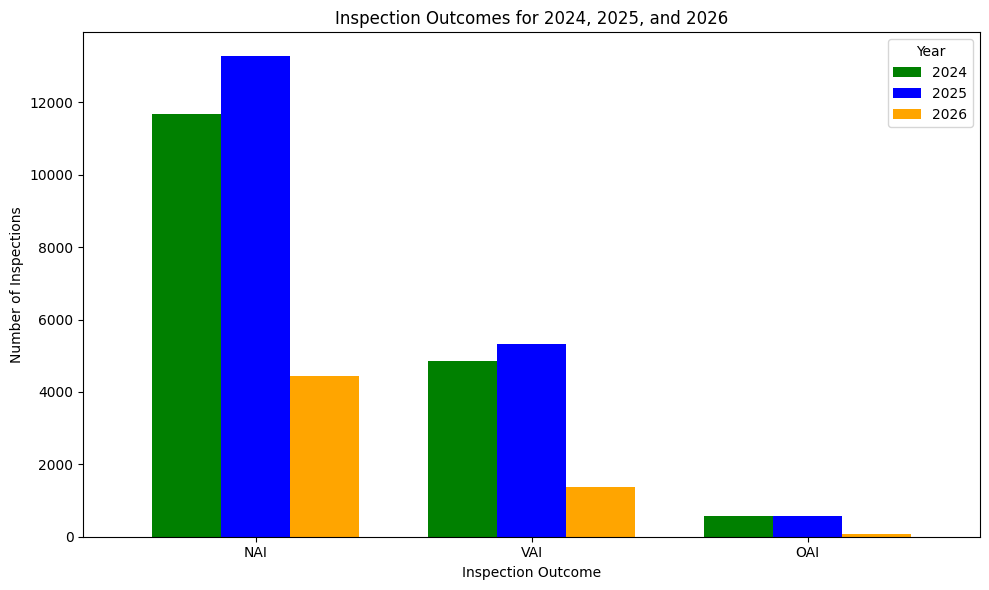

In [24]:
# Inspection outcomes for 2024, 2025, and 2026: compare with grouped bars

inspection_outcomes_2024 = (
    fda_data.loc[fda_data["Fiscal Year"] == 2024, "Inspection Outcome"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
 )

inspection_outcomes_2025 = (
    fda_data.loc[fda_data["Fiscal Year"] == 2025, "Inspection Outcome"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
 )

inspection_outcomes_2026 = (
    fda_data.loc[fda_data["Fiscal Year"] == 2026, "Inspection Outcome"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
 )

outcome_order = [0, 1, 2]
outcome_labels = {
    0: "NAI",
    1: "VAI",
    2: "OAI",
}

comparison_df = pandas.DataFrame({
    2024: inspection_outcomes_2024,
    2025: inspection_outcomes_2025,
    2026: inspection_outcomes_2026
}).reindex(outcome_order).fillna(0).astype("Int64")

ax = comparison_df.plot(
    kind="bar",
    figsize=(10, 6),
    color=["green", "blue", "orange"],
    width=0.75
)

ax.set_title("Inspection Outcomes for 2024, 2025, and 2026")
ax.set_xlabel("Inspection Outcome")
ax.set_ylabel("Number of Inspections")
ax.set_xticklabels([outcome_labels[i] for i in comparison_df.index], rotation=0)
ax.legend(title="Year")
plt.tight_layout()
plt.show()

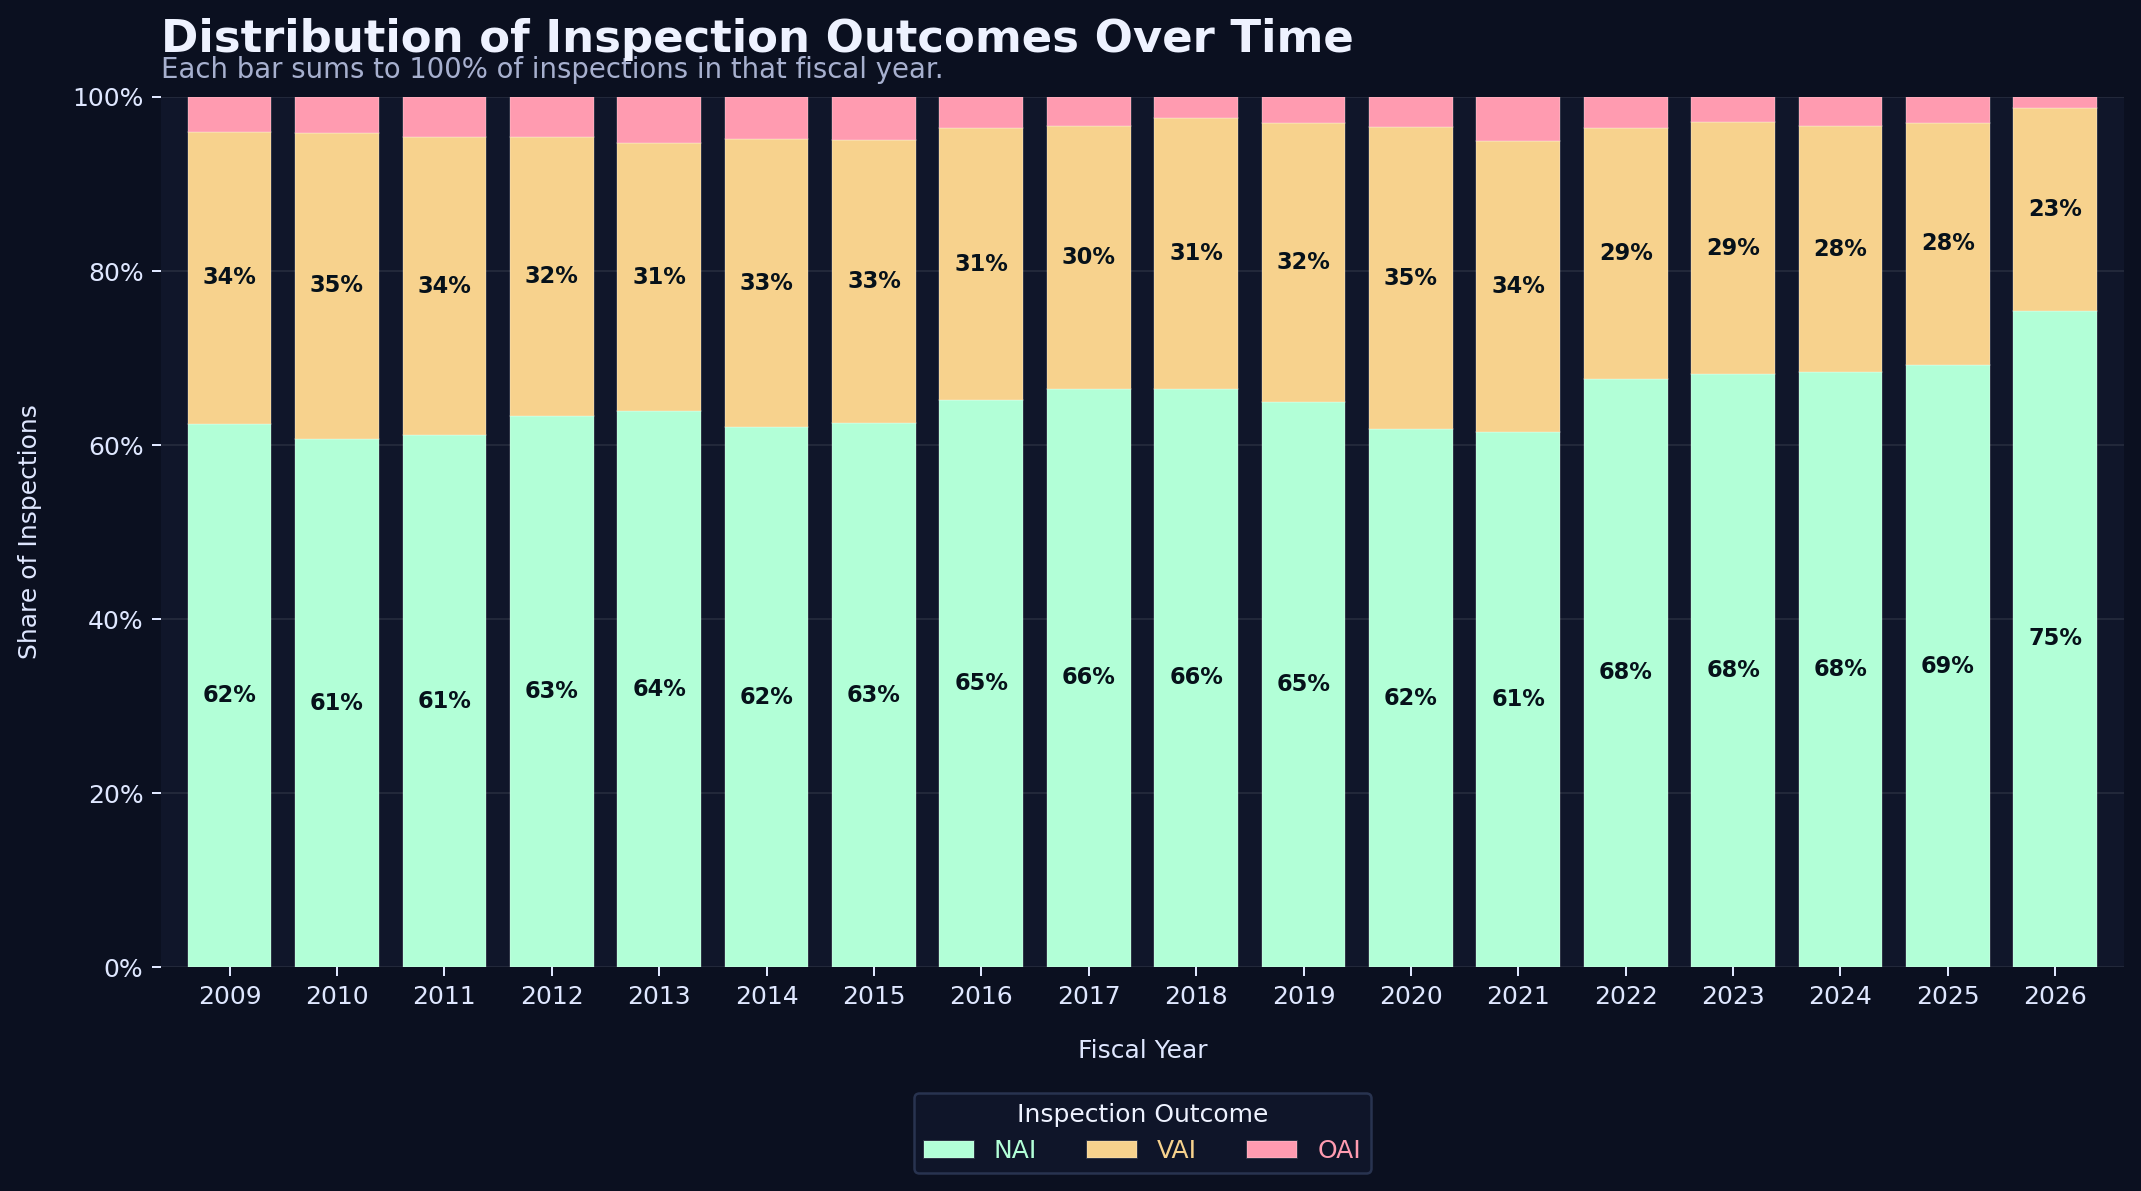

In [34]:
from pathlib import Path
from matplotlib.ticker import PercentFormatter

# Create a chart that shows the distribution of inspection outcomes across all years, and how that distribution changes over time.
# Use a stacked bar chart to show the proportion of NAI, VAI, and OAI outcomes for each year.

stacked_outcomes = (
    fda_data.groupby("Fiscal Year")["Inspection Outcome"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .reindex(sorted(fda_data["Fiscal Year"].dropna().unique()))
)
stacked_outcomes = stacked_outcomes.reindex(outcome_order, axis=1).fillna(0)

palette = ["#b2ffd7", "#f7d28d", "#ff9bb0"]
figure, ax = plt.subplots(figsize=(12, 7), dpi=180)
figure.patch.set_facecolor("#0b1020")
ax.set_facecolor("#10162a")

stacked_outcomes.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=palette,
    width=0.78,
    edgecolor=(1, 1, 1, 0.16),
    linewidth=0.7,
)

ax.set_title(
    "Distribution of Inspection Outcomes Over Time",
    loc="left",
    pad=18,
    fontsize=18,
    fontweight="bold",
    color="#eef2ff",
)
ax.text(
    0,
    1.015,
    "Each bar sums to 100% of inspections in that fiscal year.",
    transform=ax.transAxes,
    color="#a7b0cf",
    fontsize=11,
    va="bottom",
)

ax.set_xlabel("Fiscal Year", color="#dfe7ff", labelpad=12)
ax.set_ylabel("Share of Inspections", color="#dfe7ff", labelpad=12)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="y", color="white", alpha=0.08, linewidth=0.8)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
ax.tick_params(axis="x", colors="#dfe7ff", labelrotation=0)
ax.tick_params(axis="y", colors="#dfe7ff")
ax.set_xticklabels([str(int(year)) for year in stacked_outcomes.index])

for spine in ax.spines.values():
    spine.set_visible(False)

for container in ax.containers:
    labels = [f"{patch.get_height():.0%}" if patch.get_height() >= 0.08 else "" for patch in container]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="#06111a",
        fontsize=9,
        fontweight="bold",
    )

legend = ax.legend(
    title="Inspection Outcome",
    labels=[outcome_labels[i] for i in outcome_order],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=3,
    frameon=True,
    facecolor="#10162a",
    edgecolor="#2a3552",
    framealpha=0.96,
)
legend.get_title().set_color("#eef2ff")
for text, color in zip(legend.get_texts(), palette):
    text.set_color(color)

plt.tight_layout(rect=[0, 0.03, 1, 1])

output_path = Path("/Users/jao/Desktop/FDA-Inspections/Classification Distribution.png")
figure.savefig(
    output_path,
    dpi=220,
    facecolor=figure.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.28,
)
plt.show()


In [26]:
# Convert only boolean columns in fda_data_encoded to 1/0
bool_cols = fda_data_encoded.select_dtypes(include=["bool"]).columns
fda_data_encoded[bool_cols] = fda_data_encoded[bool_cols].astype("int8")

In [27]:
# How many columns in fda_data_encoded?
print(f"Number of columns in fda_data_encoded: {fda_data_encoded.shape[1]}")

Number of columns in fda_data_encoded: 26


In [28]:
# Create leakage-safe historical facility features using FEI Number
df_hist = fda_data_encoded.sort_values(["FEI Number", "Fiscal Year", "Inspection End Date"]).copy()

# Row-level history for <= 2023: uses only inspections strictly before the current row
df_hist["Past Inspections"] = df_hist.groupby("FEI Number").cumcount()
df_hist["Past NAI"] = df_hist.groupby("FEI Number")["Inspection Outcome"].transform(lambda x: (x.eq(0)).cumsum().shift(fill_value=0))
df_hist["Past VAI"] = df_hist.groupby("FEI Number")["Inspection Outcome"].transform(lambda x: (x.eq(1)).cumsum().shift(fill_value=0))
df_hist["Past OAI"] = df_hist.groupby("FEI Number")["Inspection Outcome"].transform(lambda x: (x.eq(2)).cumsum().shift(fill_value=0))

# Freeze historical counts at end of 2023 for 2024+ rows
hist_2023 = (
    df_hist.loc[df_hist["Fiscal Year"] <= 2023]
    .groupby("FEI Number")["Inspection Outcome"]
    .agg(
        Past_Inspections_2023="count",
        Past_NAI_2023=lambda s: (s == 0).sum(),
        Past_VAI_2023=lambda s: (s == 1).sum(),
        Past_OAI_2023=lambda s: (s == 2).sum(),
    )
)

future_mask = df_hist["Fiscal Year"] > 2023
df_hist.loc[future_mask, "Past Inspections"] = df_hist.loc[future_mask, "FEI Number"].map(hist_2023["Past_Inspections_2023"]).fillna(0)
df_hist.loc[future_mask, "Past NAI"] = df_hist.loc[future_mask, "FEI Number"].map(hist_2023["Past_NAI_2023"]).fillna(0)
df_hist.loc[future_mask, "Past VAI"] = df_hist.loc[future_mask, "FEI Number"].map(hist_2023["Past_VAI_2023"]).fillna(0)
df_hist.loc[future_mask, "Past OAI"] = df_hist.loc[future_mask, "FEI Number"].map(hist_2023["Past_OAI_2023"]).fillna(0)

# Write features back in original row order
fda_data_encoded[["Past Inspections", "Past NAI", "Past VAI", "Past OAI"]] = df_hist[["Past Inspections", "Past NAI", "Past VAI", "Past OAI"]].reindex(fda_data_encoded.index).fillna(0).astype("int32")

In [29]:
# Drop end date features and ex post features that wouldn't be available at the time of prediction
fda_data_encoded = fda_data_encoded.drop(columns=['FEI Number','Inspection End Date', 'Inspection Year', 'Inspection Month', 'Inspection Day','Posted Citations','FMD-145 Date','Additional Details',
                                                  'Has Additional Details','Has FMD-145 Date','Inspection ID'])

In [30]:
# Set seeds for reproducibility
import random
import numpy as np
import lightgbm as lgb
SEED = 5
random.seed(SEED)
np.random.seed(SEED)
trials = 5

In [31]:
# Set up LGBM + Optuna for classification of Inspection Outcome
import optuna
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Define target and features
y = fda_data_encoded["Inspection Outcome"].astype(int)

# Exclude target and known leakage column
exclude_cols = {"Inspection Outcome", "Classification"}
X = fda_data_encoded.drop(columns=[c for c in exclude_cols if c in fda_data_encoded.columns]).copy()

# Keep categorical columns for LightGBM native handling
categorical_cols = [
    'State','Product Type', 'Project Area', 'Country/Area',
    'Presidential Administration', 'Region', 'US_Region'
 ]
categorical_features_raw = [c for c in categorical_cols if c in X.columns]
for c in categorical_features_raw:
    if isinstance(X[c].dtype, pandas.CategoricalDtype) and "Unknown" not in X[c].cat.categories:
        X[c] = X[c].cat.add_categories(["Unknown"])
    X[c] = X[c].fillna("Unknown").astype("category")

# LightGBM requires feature names without special JSON characters
raw_cols = pandas.Index(X.columns).astype(str)
safe_cols = raw_cols.str.replace(r"[^0-9A-Za-z_]+", "_", regex=True).str.strip("_")

# Ensure unique column names after sanitization
seen = {}
unique_safe_cols = []
for c in safe_cols:
    n = seen.get(c, 0)
    unique_safe_cols.append(c if n == 0 else f"{c}_{n}")
    seen[c] = n + 1

col_map = dict(zip(raw_cols, unique_safe_cols))
X = X.rename(columns=col_map)
categorical_features = [col_map[c] for c in categorical_features_raw if c in col_map]

# Time-based split:
# Train: <= 2023, Eval: 2024, Test: 2025 and 2026
train_mask = fda_data_encoded["Fiscal Year"] <= 2023
eval_mask = fda_data_encoded["Fiscal Year"] == 2024
test_mask = fda_data_encoded["Fiscal Year"].isin([2025, 2026])

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_eval, y_eval = X.loc[eval_mask], y.loc[eval_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

def objective(trial):
    params = {
        "objective": "multiclass",
        "num_class": 3,
        "random_state": 42,
        "n_jobs": -1,
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 16),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    clf = LGBMClassifier(**params)
    clf.fit(
        X_train,
        y_train,
        eval_set=[(X_eval, y_eval)],
        eval_metric="multi_logloss",
        categorical_feature=categorical_features,
        callbacks=[early_stopping(30, verbose=False)],
    )

    y_eval_pred = clf.predict(X_eval)
    return f1_score(y_eval, y_eval_pred, average="macro")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=trials, show_progress_bar=True)

print("Best macro-F1:", study.best_value)
print("Best params:", study.best_params)
print("Number of categorical features used:", len(categorical_features))

# Train final model with best params
best_params = {
    **study.best_params,
    "objective": "multiclass",
    "num_class": 3,
    "random_state": 42,
    "n_jobs": -1,
}
model = LGBMClassifier(**best_params)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_eval, y_eval)],
    eval_metric="multi_logloss",
    categorical_feature=categorical_features,
    callbacks=[early_stopping(30, verbose=False)],
)

# Predict on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Evaluate model performance
print(classification_report(y_test, y_pred, target_names=["NAI", "VAI", "OAI"]))
print(confusion_matrix(y_test, y_pred))

# Probability output for each outcome
probability_df = pandas.DataFrame(
    y_proba,
    columns=["P(NAI)", "P(VAI)", "P(OAI)"],
    index=X_test.index,
 )
probability_df.head()

[I 2026-04-19 21:05:02,081] A new study created in memory with name: no-name-72257167-3739-4fdd-aeba-38f0f88165cf


  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 288282, number of used features: 17
[LightGBM] [Info] Start training from score -0.447467
[LightGBM] [Info] Start training from score -1.136914
[LightGBM] [Info] Start training from score -3.220202
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

,P(NAI),P(VAI),P(OAI)
0,0.796061,0.197145,0.006794
1,0.761856,0.228759,0.009385
2,0.858296,0.139071,0.002632
3,0.823268,0.171279,0.005452
4,0.818134,0.162926,0.018940


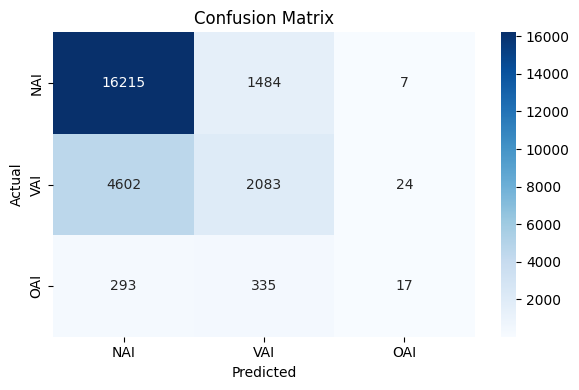

Test Accuracy: 0.7308
Test Macro-F1 Score: 0.4257


,P(NAI),P(VAI),P(OAI)
0,0.796061,0.197145,0.006794
1,0.761856,0.228759,0.009385
2,0.858296,0.139071,0.002632
3,0.823268,0.171279,0.005452
4,0.818134,0.162926,0.018940
5,0.472605,0.515006,0.012389
6,0.957409,0.041752,0.000839
7,0.234660,0.580947,0.184394
8,0.487804,0.395327,0.116869
9,0.619091,0.366810,0.014099


In [32]:
# Show me confusion matrix as heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NAI", "VAI", "OAI"], yticklabels=["NAI", "VAI", "OAI"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Also show overall accuracy and macro-F1 score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Macro-F1 Score: {macro_f1:.4f}")

# View the first few probability predictions
probability_df.head(10)

In [35]:
# Let me know names of the variables that were used by the model to predict the outcomes, and which of those variables were categorical features that LightGBM handled natively.
print("Variables used for prediction:")
print(X_train.columns.tolist())
print("\nCategorical features handled natively by LightGBM:")
print(categorical_features) 

Variables used for prediction:
['State', 'Zip', 'Country_Area', 'Fiscal_Year', 'Project_Area', 'Product_Type', 'Presidential_Administration', 'President_Party', 'Years_Since_Admin_Start', 'Product_Type_Warning_Letter_Frequency', 'Product_Type_Injunction_Frequency', 'Region', 'US_Region', 'Past_Inspections', 'Past_NAI', 'Past_VAI', 'Past_OAI']

Categorical features handled natively by LightGBM:
['State', 'Product_Type', 'Project_Area', 'Country_Area', 'Presidential_Administration', 'Region', 'US_Region']


In [36]:
# Try different model to optimize for F1 score of OAI (class 2) instead of macro-F1
def objective_oai(trial):
    params = {
        "objective": "multiclass",
        "num_class": 3,
        "random_state": 42,
        "n_jobs": -1,
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 16),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    clf = LGBMClassifier(**params)
    clf.fit(
        X_train,
        y_train,
        eval_set=[(X_eval, y_eval)],
        eval_metric="multi_logloss",
        categorical_feature=categorical_features,
        callbacks=[early_stopping(30, verbose=False)],
    )

    y_eval_pred = clf.predict(X_eval)
    return f1_score(y_eval, y_eval_pred, average=None)[2]
study_oai = optuna.create_study(direction="maximize")
study_oai.optimize(objective_oai, n_trials=trials, show_progress_bar=True)
print("Best OAI F1:", study_oai.best_value)
print("Best params for OAI F1:", study_oai.best_params)

[I 2026-04-19 18:32:06,922] A new study created in memory with name: no-name-6e73c205-b471-4a7a-8de3-52bd1088eeff


  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009931 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 288282, number of used features: 17
[LightGBM] [Info] Start training from score -0.447467
[LightGBM] [Info] Start training from score -1.136914
[LightGBM] [Info] Start training from score -3.220202
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008113 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 288282, number of used features: 17
[LightGBM] [Info] Start training from score -0.447467
[LightGBM] [Info] Start training from score -1.136914
[LightGBM] [Info] Start training from score -3.220202
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

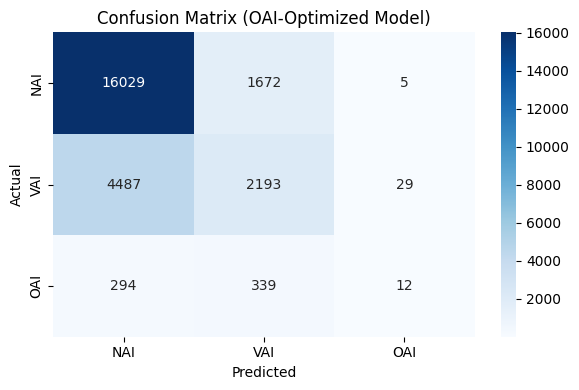

Test Accuracy (OAI model): 0.7276
Test Macro-F1 (OAI model): 0.4230


,P(NAI),P(VAI),P(OAI)
0,0.784274,0.209561,0.006165
1,0.736367,0.253606,0.010027
2,0.855306,0.142891,0.001803
3,0.824661,0.169601,0.005738
4,0.817275,0.162900,0.019825
5,0.469067,0.519044,0.011889
6,0.963115,0.036117,0.000769
7,0.251451,0.550362,0.198186
8,0.422393,0.470241,0.107367
9,0.651350,0.338390,0.010260


In [37]:
# Show confusion matrix for OAI-optimized model (heatmap) + probabilities
best_params_oai = {
    **study_oai.best_params,
    "objective": "multiclass",
    "num_class": 3,
    "random_state": 42,
    "n_jobs": -1,
}

model_oai = LGBMClassifier(**best_params_oai)
model_oai.fit(
    X_train,
    y_train,
    eval_set=[(X_eval, y_eval)],
    eval_metric="multi_logloss",
    categorical_feature=categorical_features,
    callbacks=[early_stopping(30, verbose=False)],
)

# Predictions
y_pred_oai = model_oai.predict(X_test)
y_proba_oai = model_oai.predict_proba(X_test)

# Classification report
print("Classification Report for OAI-Optimized Model:")
print(classification_report(y_test, y_pred_oai, target_names=["NAI", "VAI", "OAI"]))

# Confusion matrix heatmap
cm_oai = confusion_matrix(y_test, y_pred_oai)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_oai,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NAI", "VAI", "OAI"],
    yticklabels=["NAI", "VAI", "OAI"]
)
plt.title("Confusion Matrix (OAI-Optimized Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Accuracy + macro-F1
accuracy_oai = accuracy_score(y_test, y_pred_oai)
macro_f1_oai = f1_score(y_test, y_pred_oai, average="macro")
print(f"Test Accuracy (OAI model): {accuracy_oai:.4f}")
print(f"Test Macro-F1 (OAI model): {macro_f1_oai:.4f}")

# Probability output
probability_df_oai = pandas.DataFrame(
    y_proba_oai,
    columns=["P(NAI)", "P(VAI)", "P(OAI)"],
    index=X_test.index
)
probability_df_oai.head(10)

In [38]:
# Try different model optimizing for accuracy

def objective_acc(trial):
    params = {
        "objective": "multiclass",
        "num_class": 3,
        "random_state": 42,
        "n_jobs": -1,
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 16),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    clf = LGBMClassifier(**params)
    clf.fit(
        X_train,
        y_train,
        eval_set=[(X_eval, y_eval)],
        eval_metric="multi_logloss",
        categorical_feature=categorical_features,
        callbacks=[early_stopping(30, verbose=False)],
    )

    y_eval_pred = clf.predict(X_eval)
    return accuracy_score(y_eval, y_eval_pred)
study_acc = optuna.create_study(direction="maximize")
study_acc.optimize(objective_acc, n_trials=trials, show_progress_bar=True)
print("Best Accuracy:", study_acc.best_value)
print("Best params for Accuracy:", study_acc.best_params)

[I 2026-04-19 18:33:41,626] A new study created in memory with name: no-name-3cb97866-4cc3-45fb-9208-6a9b52d8746f


  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 288282, number of used features: 17
[LightGBM] [Info] Start training from score -0.447467
[LightGBM] [Info] Start training from score -1.136914
[LightGBM] [Info] Start training from score -3.220202
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005020 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 288282, number of used features: 17
[LightGBM] [Info] Start training from score -0.447467
[LightGBM] [Info] Start training from score -1.136914
[LightGBM] [Info] Start training from score -3.220202
Classification Report for Accuracy-Optimized Model:
              precision    recall  f1-score   support

         NAI       0.77      0.90      0.83     17706
         VAI       0.52      0.35      0.41      6709
         OAI       0.27      0.01      0.03       645

    accuracy                           0.73     25060
   macro avg       0.52      0.42      0.42     25060
weighted avg       0.69      0.73      0.70     25060



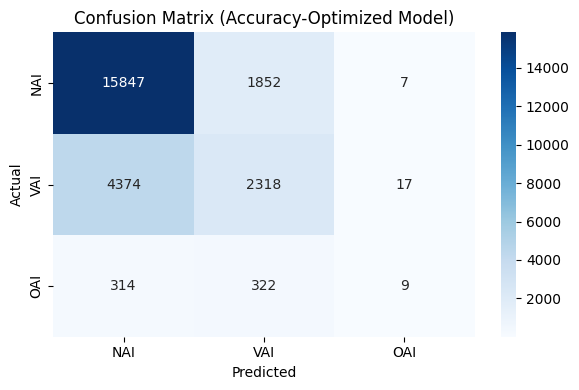

Test Accuracy (Accuracy model): 0.7252
Test Macro-F1 (Accuracy model): 0.4231


,P(NAI),P(VAI),P(OAI)
0,0.781390,0.207511,0.011099
1,0.671892,0.317514,0.010595
2,0.831649,0.163407,0.004944
3,0.840656,0.153066,0.006277
4,0.819908,0.159309,0.020783
5,0.436731,0.551936,0.011333
6,0.933109,0.062926,0.003965
7,0.244278,0.531458,0.224264
8,0.471151,0.432326,0.096523
9,0.667507,0.318537,0.013956


In [40]:
# Show confusion matrix for accuracy-optimized model + probabilities
best_params_acc = {
    **study_acc.best_params,
    "objective": "multiclass",
    "num_class": 3,
    "random_state": 42,
    "n_jobs": -1,
}

model_acc = LGBMClassifier(**best_params_acc)
model_acc.fit(
    X_train,
    y_train,
    eval_set=[(X_eval, y_eval)],
    eval_metric="multi_logloss",
    categorical_feature=categorical_features,
    callbacks=[early_stopping(30, verbose=False)],
)

# Predictions
y_pred_acc = model_acc.predict(X_test)
y_proba_acc = model_acc.predict_proba(X_test)

# Classification report
print("Classification Report for Accuracy-Optimized Model:")
print(classification_report(y_test, y_pred_acc, target_names=["NAI", "VAI", "OAI"]))

# Confusion matrix heatmap
cm_acc = confusion_matrix(y_test, y_pred_acc)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_acc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NAI", "VAI", "OAI"],
    yticklabels=["NAI", "VAI", "OAI"]
)
plt.title("Confusion Matrix (Accuracy-Optimized Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Accuracy + macro-F1
accuracy_acc = accuracy_score(y_test, y_pred_acc)
macro_f1_acc = f1_score(y_test, y_pred_acc, average="macro")
print(f"Test Accuracy (Accuracy model): {accuracy_acc:.4f}")
print(f"Test Macro-F1 (Accuracy model): {macro_f1_acc:.4f}")

# Probability output
probability_df_acc = pandas.DataFrame(
    y_proba_acc,
    columns=["P(NAI)", "P(VAI)", "P(OAI)"],
    index=X_test.index
)
probability_df_acc.head(10)

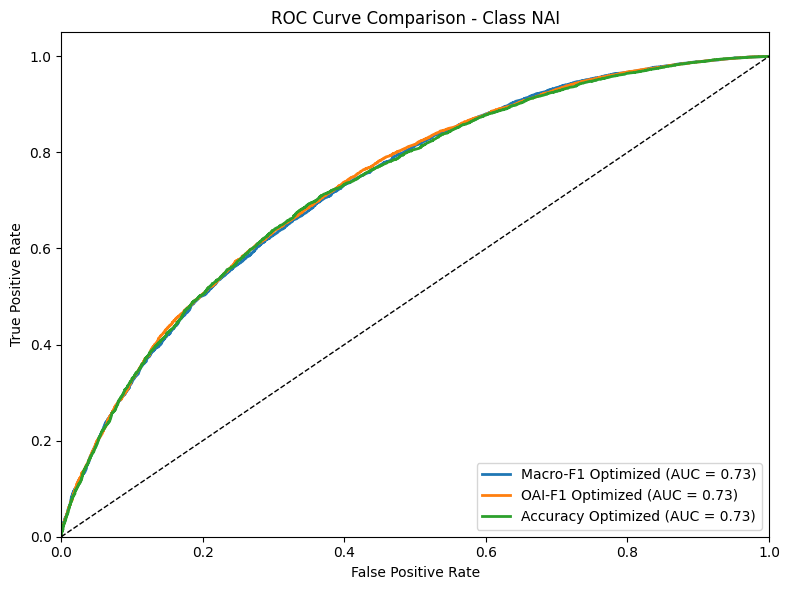

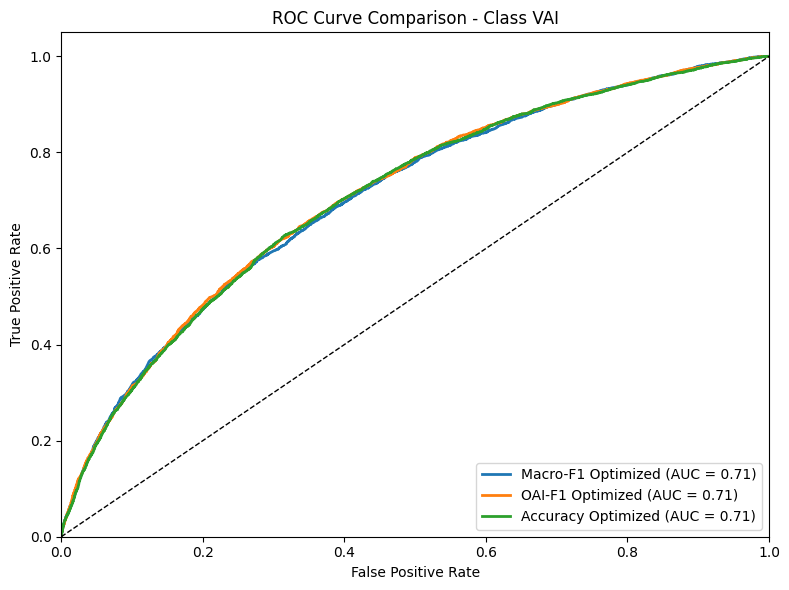

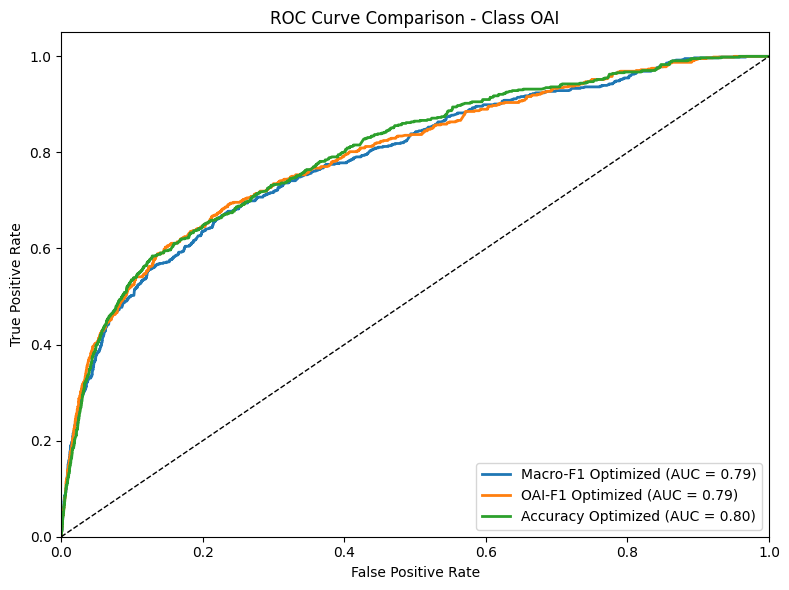

In [42]:
from sklearn.metrics import roc_curve, auc

def plot_roc_by_class(model_probas, model_names, y_test, outcome_labels):
    for class_idx in range(3):
        plt.figure(figsize=(8, 6))
        y_true_bin = (y_test == class_idx).astype(int)

        for y_proba_model, name in zip(model_probas, model_names):
            fpr, tpr, _ = roc_curve(y_true_bin, y_proba_model[:, class_idx])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")

        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve Comparison - Class {outcome_labels[class_idx]}")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

plot_roc_by_class(
    model_probas=[y_proba, y_proba_oai, y_proba_acc],
    model_names=["Macro-F1 Optimized", "OAI-F1 Optimized", "Accuracy Optimized"],
    y_test=y_test,
    outcome_labels=outcome_labels
)


In [54]:
from pathlib import Path
import json

repo_root = Path('/Users/jao/Desktop/FDA-Inspections')
assets_dir = repo_root / 'site' / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)

model_dump = model.booster_.dump_model()
category_orders = {k: (v if 'Unknown' in v else v + ['Unknown']) for k, v in cat_orders.items()}

export_payload = {
    'feature_names': list(X_train.columns),
    'categorical_features': categorical_features,
    'category_orders': category_orders,
    'best_params': best_params,
    'metrics': {
        'eval_macro_f1': float(macro_f1),
        'eval_accuracy': float(accuracy),
    },
    'label_names': ['NAI', 'VAI', 'OAI'],
    'model_dump': model_dump,
    'state_to_region': state_to_region,
    'country_to_region': country_to_region,
    'product_type_warning_rank': product_type_rankings,
    'product_type_injunction_rank': injunction_rankings,
    'president_party_map': {'Obama': 1, 'Trump': 0, 'Biden': 1},
}

(assets_dir / 'fda_model_export.json').write_text(json.dumps(export_payload), encoding='utf-8')
print('Exported fitted model, category orders, metrics, and feature maps to site/assets/fda_model_export.json')

Exported fitted model, category orders, metrics, and feature maps to site/assets/fda_model_export.json


In [48]:
dump = model.booster_.dump_model()
print('num_trees:', len(dump['tree_info']))
print('first 5 shrinkage values:', [t.get('shrinkage') for t in dump['tree_info'][:5]])
print('first tree_info keys:', list(dump['tree_info'][0].keys()))
root = dump['tree_info'][0]['tree_structure']
print('root split_feature:', root.get('split_feature'))
print('root threshold:', root.get('threshold'))
print('root decision_type:', root.get('decision_type'))
print('root default_left:', root.get('default_left'))

num_trees: 162
first 5 shrinkage values: [1, 1, 1, 0.128784, 0.128784]
first tree_info keys: ['tree_index', 'num_leaves', 'num_cat', 'shrinkage', 'tree_structure']
root split_feature: 15
root threshold: 1.0000000180025095e-35
root decision_type: <=
root default_left: True


In [51]:
cat_orders = {c: list(X_train[c].cat.categories) for c in categorical_features}
print('categorical orders captured:', {k: len(v) for k, v in cat_orders.items()})

def cat_code(feature_name, value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return -1
    categories = cat_orders.get(feature_name)
    if categories is None:
        return -1
    try:
        return categories.index(value)
    except ValueError:
        return -1

def eval_tree(node, row, feature_names, left_when_in_set=True):
    while 'leaf_value' not in node:
        feature_name = feature_names[node['split_feature']]
        threshold = node['threshold']
        if feature_name in cat_orders or (isinstance(threshold, str) and '||' in threshold):
            allowed = {int(x) for x in str(threshold).split('||') if x != ''}
            value = cat_code(feature_name, row[feature_name])
            go_left = value in allowed if left_when_in_set else value not in allowed
        else:
            raw_value = row[feature_name]
            value = float(raw_value) if raw_value is not None else np.nan
            if np.isnan(value):
                go_left = bool(node['default_left'])
            elif node['decision_type'] in ('<=', '<= '):
                go_left = value <= float(threshold)
            elif node['decision_type'] == '<':
                go_left = value < float(threshold)
            else:
                go_left = value == float(threshold)
        node = node['left_child'] if go_left else node['right_child']
    return float(node['leaf_value'])

def manual_predict_proba(X, left_when_in_set=True, use_tree_shrinkage=True):
    rows = []
    feature_names = X.columns.tolist()
    for _, row in X.iterrows():
        raw = np.zeros(3, dtype=float)
        for tree_pos, tree in enumerate(trees):
            cls = tree_pos % 3
            leaf = eval_tree(tree['tree_structure'], row, feature_names, left_when_in_set=left_when_in_set)
            contrib = leaf * float(tree.get('shrinkage', 1.0)) if use_tree_shrinkage else leaf
            raw[cls] += contrib
        shifted = raw - raw.max()
        probs = np.exp(shifted) / np.exp(shifted).sum()
        rows.append(probs)
    return np.array(rows)

sample = X_train.iloc[:5].copy()
target = model.predict_proba(sample)
print('target:')
print(target)
print('manual left_when_in_set=True, shrinkage=True')
print(manual_predict_proba(sample, True, True))
print('manual left_when_in_set=False, shrinkage=True')
print(manual_predict_proba(sample, False, True))
print('manual left_when_in_set=True, shrinkage=False')
print(manual_predict_proba(sample, True, False))

categorical orders captured: {'State': 58, 'Product_Type': 7, 'Project_Area': 25, 'Country_Area': 144, 'Presidential_Administration': 4, 'Region': 7, 'US_Region': 6}
target:
[[0.35961433 0.62844822 0.01193745]
 [0.16819192 0.51443849 0.31736959]
 [0.50905713 0.45321047 0.0377324 ]
 [0.55243976 0.39075221 0.05680803]
 [0.40037831 0.57771495 0.02190674]]
manual left_when_in_set=True, shrinkage=True
[[0.59625246 0.37095963 0.03278792]
 [0.52092958 0.4043297  0.07474073]
 [0.61119109 0.34713258 0.04167633]
 [0.62927961 0.33052556 0.04019484]
 [0.59134543 0.37368119 0.03497339]]
manual left_when_in_set=False, shrinkage=True
[[0.65782877 0.28438864 0.05778258]
 [0.61480866 0.33974186 0.04544949]
 [0.57777278 0.36987035 0.05235688]
 [0.68693447 0.27923867 0.03382686]
 [0.67558911 0.29139255 0.03301834]]
manual left_when_in_set=True, shrinkage=False
[[0.35961433 0.62844822 0.01193745]
 [0.16819192 0.51443849 0.31736959]
 [0.50905713 0.45321047 0.0377324 ]
 [0.55243976 0.39075221 0.05680803]
 [

Unique values for State: ['South Carolina' 'Illinois' 'Pennsylvania' 'Ohio' 'Nevada' 'Texas'
 'Washington' 'New York' 'Utah' 'Massachusetts' 'California' 'Connecticut'
 'Florida' 'Minnesota' 'Missouri' 'Delaware' 'Iowa' 'New Jersey'
 'Wisconsin' 'Hawaii' 'Michigan' '-' 'Indiana' 'Georgia' 'Maryland'
 'Rhode Island' 'Colorado' 'Kentucky' 'Arizona' 'Oklahoma' 'Kansas'
 'Louisiana' 'New Hampshire' 'Maine' 'Puerto Rico' 'Alabama'
 'North Carolina' 'Tennessee' 'Virginia' 'West Virginia' 'Mississippi'
 'Arkansas' 'Idaho' 'Nebraska' 'District of Columbia' 'New Mexico'
 'South Dakota' 'Oregon' 'North Dakota' 'Vermont' 'Wyoming' 'Alaska'
 'Montana' 'Virgin Islands' 'Guam' 'Northern Mariana Islands'
 'American Samoa']
Unique values for State when Country is not US: ['-']
